<a href="https://colab.research.google.com/github/fatihonay/Neural-Variability-/blob/main/TrialbyTrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variability Across Trials
We know that the brain is active every moment independent of conditions and circumsitances (of course we assume that the subject is alive). In this mini tutorial, I will demonstrate a specifiv type of neural variabiltiy. Let's talk about the **trial-by-trial** variability.

The classical experimental protocol in cognitive and behavioral neuroscience studies includes repetitive execution of specific tasks to understand task-specific changes within the brain. However, neural activity represents variability due to the both instrinsic neural dynamics and unknown external noise. Researchers try to collect high amount of data by performing multiple repetitive trials to deal with noise. The classical way is to take average of these multiple trials and thus incresing the SNR of the task related neural activity.

Let's observe this variability with simple Python and EEG example.  


## 1. Install and Import Libraries
We will need MNE-Python library to import and pre-process EEG data. We also use Numpy for math operations and Matplotlib for visualization. If you dont have these libraris, install them before starting.


In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

print("Ready to analyze EEG, Yuppii!")

Ready to analyze EEG, Yuppii!


## Load and pre-process Data
In this tutorial, we will use a dataset from `MNE-Python` library. It is a standard cognitive task to study conflict effect and known as [`Flanker task`](https://en.wikipedia.org/wiki/Eriksen_flanker_task).

We will load data and then perform simple pre-processing of `0.1-30`Hz band-pass filtering and `common-average`referencing.  Normally, there are lots of details associated with pre-processing steps. However, this is not a focus of this tutorial.


In [2]:
# Get the dataset path
data_path = mne.datasets.erp_core.data_path()

# Sometimes file path may not be standard, it is better to look where the file is
search_pattern = os.path.join(data_path, '*Flankers_eeg.fif')
found_files    = glob.glob(search_pattern, recursive=True)

# Print exact location
raw_fname = found_files[0] # fname must be an instance of path-like not list (I got this error when not use [0])
print(f"Found file at: {raw_fname}")

# MNE command: Import data
raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw.pick_types(meg=False, eeg=True, eog=False)

# ---Simple pre-processing ---
# FILTER: Remove slow drift and high frequency sharp noise
raw.filter(0.1, 30, fir_design='firwin')

# 3. RE-REFERENCE: Use the average of all channels as the new zero
raw.set_eeg_reference('average', projection=True)
# ---Simple pre-processing ---

# ERP CORE uses text labels (Annotations). We should convert them to integer IDs.
events, event_id_dict = mne.events_from_annotations(raw)

print(f"\nData Loaded. Channels: {len(raw.ch_names)}")
print(f"\nChannels: {raw.ch_names}")

# I want to see which events/stimuli are used in the data
event_id_dict

Found file at: /root/mne_data/MNE-ERP-CORE-data/ERP-CORE_Subject-001_Task-Flankers_eeg.fif
Opening raw data file /root/mne_data/MNE-ERP-CORE-data/ERP-CORE_Subject-001_Task-Flankers_eeg.fif...
    Range : 0 ... 935935 =      0.000 ...   913.999 secs
Ready.
Reading 0 ... 935935  =      0.000 ...   913.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)

EEG channel type selected for re-referencing


{np.str_('response/left'): 1,
 np.str_('response/right'): 2,
 np.str_('stimulus/compatible/target_left'): 3,
 np.str_('stimulus/compatible/target_right'): 4,
 np.str_('stimulus/incompatible/target_left'): 5,
 np.str_('stimulus/incompatible/target_right'): 6}

# Extract Epochs and Visualize ERP
We found which event types dataset includes. You can see the table of the events and corresponding IDs which are automatically converted by `events_from_annotations` function.


##### Stimulus / Response ID Mapping

| Category   | Condition     | Target Direction | ID |
|-----------|---------------|------------------|----|
| Response  | Left           | –                | 1  |
| Response  | Right          | –                | 2  |
| Stimulus  | Compatible     | Left             | 3  |
| Stimulus  | Compatible     | Right            | 4  |
| Stimulus  | Incompatible   | Left             | 5  |
| Stimulus  | Incompatible   | Right            | 6  |

We will extract epoch for compatible and incompatible stimuli. Note that epochs will be around stimulus onset namely `0 ms`. Since this is cognitive conflict task, we will focus on channel `FCz`. You can choose other channels for further inquiry. When we visualize average ERP component, we can easily see how task related activity arises.




Used Annotations descriptions: [np.str_('response/left'), np.str_('response/right'), np.str_('stimulus/compatible/target_left'), np.str_('stimulus/compatible/target_right'), np.str_('stimulus/incompatible/target_left'), np.str_('stimulus/incompatible/target_right')]
Not setting metadata
200 matching events found
Setting baseline interval to [-0.25, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 200 events and 1025 original time points ...
    Rejecting  epoch based on EEG : ['F7']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['F7', 'F4', 'F8', 'FC4']
    Rejecting  epoch based on EEG : ['FP2']
4 bad epochs dropped
Not setting metadata
400 matching events found
Setting baseline interval to [-0.25, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data 

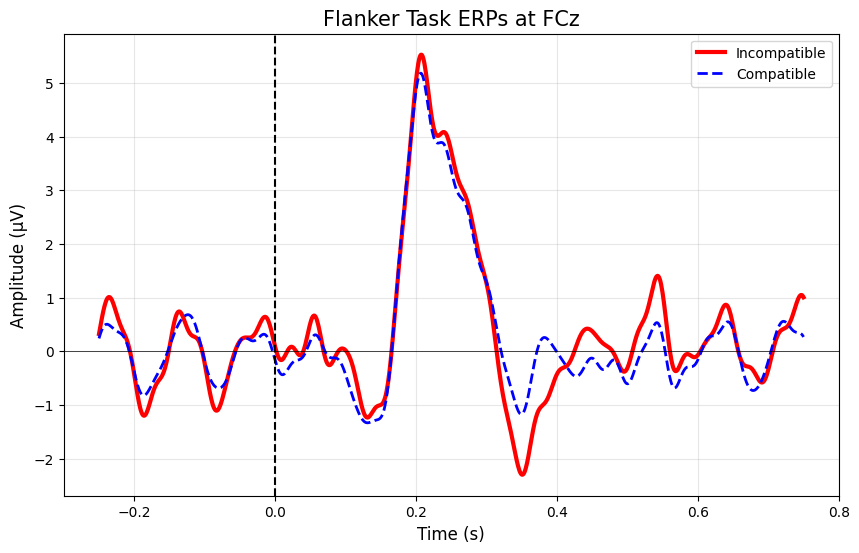

In [27]:
events, event_id_dict = mne.events_from_annotations(raw)

# Get IDs for Compatible  and Incompatible stimuli
ids_incomp = [val for key, val in event_id_dict.items() if 'incompatible' in key]
ids_comp   = [val for key, val in event_id_dict.items() if 'compatible' in key]


# 1. Define the rejection threshold
reject_criteria = dict(eeg=300e-6)  # 300 µV


# 2. Create epochs around 0 stimilus onset
tmin, tmax = -0.25, 0.75
epochs_incomp = mne.Epochs(raw, events, event_id=ids_incomp,
                           tmin=tmin, tmax=tmax,
                           baseline=(None, 0),
                           reject=reject_criteria,
                           preload=True)
epochs_comp   = mne.Epochs(raw, events, event_id=ids_comp,
                           tmin=tmin,
                           tmax=tmax,
                           reject=reject_criteria,
                           baseline=(None, 0),
                           preload=True)

# 3. Get the average (ERP) for Cz channel
target_channel = 'FCz'
evoked_incomp  = epochs_incomp.average().pick(target_channel)
evoked_comp    = epochs_comp.average().pick(target_channel)

# 4. Visualize
plt.figure(figsize=(10, 6))

# Plot Incompatible (Red)
plt.plot(evoked_incomp.times, evoked_incomp.data[0] * 1e6, color='red', linewidth=3, label='Incompatible')

# Plot Compatible (Blue)
plt.plot(evoked_comp.times, evoked_comp.data[0] * 1e6, color='blue', linewidth=2, linestyle='--', label='Compatible')

plt.title(f"Flanker Task ERPs at {target_channel}", fontsize=15)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude (µV)", fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ovewiev of Trials

Okayy! After getting ERP, it is time to see how single trial EEG signals dynamically fluctuate. I wanted to show this in two different ways using `heatmap` and individual plots.

In the first plot, we can see the how strenght of neural activity distributed randomly when the task is absence. Once stimulus applied, we can observe aligment of neural activity around `200 ms` due to the imconpatible Flanker task effect. This is really  nice figure. You should be happy now :)

In the second plot, we can easily see that how single EEG trials fluctuate in a crazy manner. It just seems random to naked eyes.

```

Neural variability across trials is inevitable, don't panic amd learn to dance with it !

```

Not setting metadata
196 matching events found
No baseline correction applied
0 projection items activated


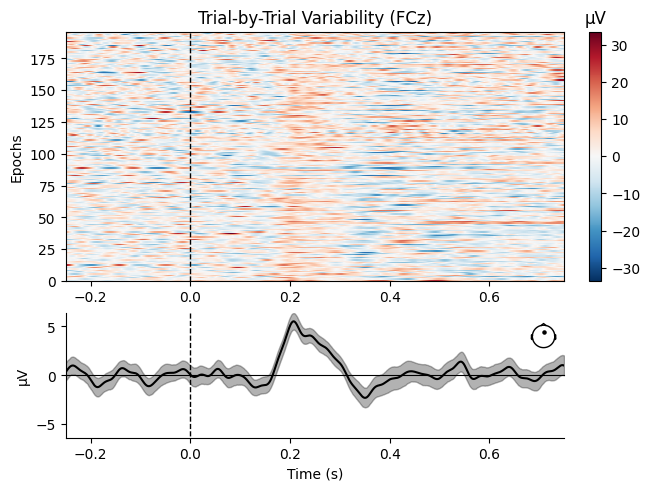

Plotting single trials...


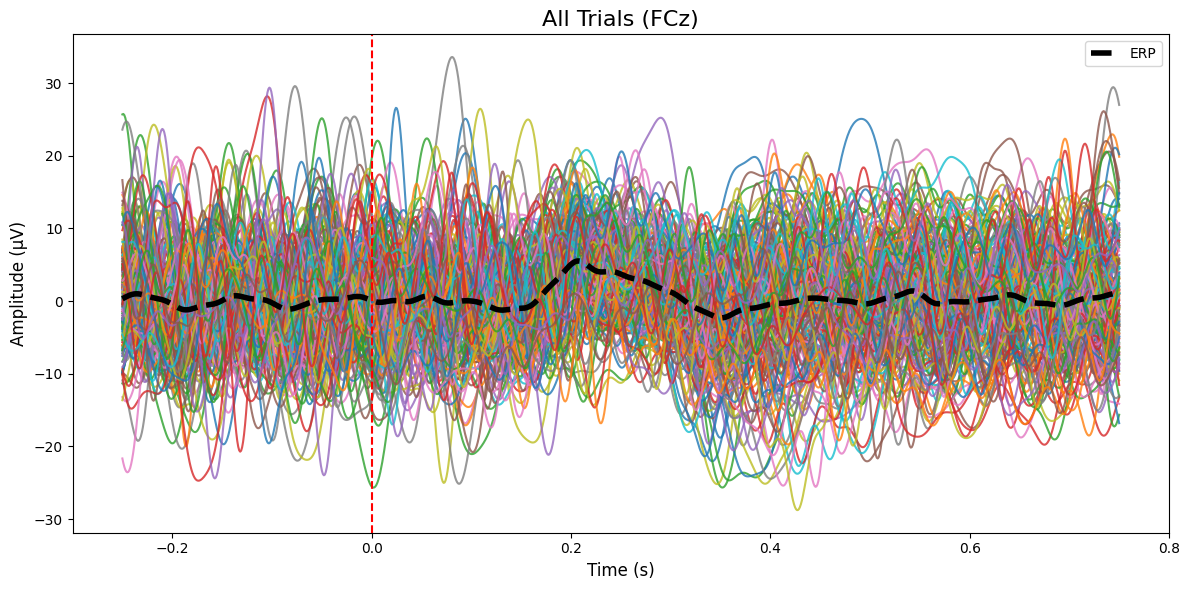

In [28]:
# 1. Trials in Heatmap
fig = mne.viz.plot_epochs_image(epochs_incomp, picks=target_channel,
                                title=f"Trial-by-Trial Variability ({target_channel})",
                                combine=None, show=True)[0] # This function automatically stacks trials, we are lucky :)

# 2. Get incompatible data
subset_data = np.squeeze(epochs_incomp.get_data(picks=[target_channel]))
times       = epochs_incomp.times
plt.figure(figsize=(12, 6))

print('Plotting single trials...')
# Plot all trials
plt.plot(times, subset_data.T * 1e6, alpha=0.8, linewidth=1.5)

# Plot the average (ERP)
plt.plot(times, evoked_incomp.data[0] * 1e6, color='black', linewidth=4, linestyle='--', label='ERP')

plt.title(f"All Trials ({target_channel})", fontsize=16)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude (µV)", fontsize=12)
plt.axvline(0, color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()